<a href="https://colab.research.google.com/github/mariamMohammed0/Drug-Release-Tracking/blob/main/Drug_Release_Tracking_Reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [6]:

#dss004: 4th-order finite difference — first derivative
def dss004(xl, xu, n, u):
    ux  = np.zeros(n)
    dx  = (xu - xl) / (n - 1)
    r4  = 1.0 / (12.0 * dx)

    for i in range(2, n - 2):
        ux[i] = r4 * (-u[i+2] + 8*u[i+1] - 8*u[i-1] + u[i-2])

    ux[0]   = r4 * (-25*u[0] + 48*u[1] - 36*u[2] + 16*u[3] -  3*u[4])
    ux[1]   = r4 * ( -3*u[0] - 10*u[1] + 18*u[2] -  6*u[3] +    u[4])
    ux[n-2] = r4 * (   -u[n-5] +  6*u[n-4] - 18*u[n-3] + 10*u[n-2] +  3*u[n-1])
    ux[n-1] = r4 * (  3*u[n-5] - 16*u[n-4] + 36*u[n-3] - 48*u[n-2] + 25*u[n-1])
    return ux

#dss044: 4th-order finite difference — second derivative (with BCs)
def dss044(xl, xu, n, u, ux, nl, nu):
    uxx = np.zeros(n)
    dx  = (xu - xl) / (n - 1)
    r4  = 1.0 / (12.0 * dx**2)

    for i in range(2, n - 2):
        uxx[i] = r4 * (-u[i+2] + 16*u[i+1] - 30*u[i] + 16*u[i-1] - u[i-2])

    uxx[1]   = r4 * (-u[0] + 16*u[1] - 30*u[2] + 16*u[3] - u[4])
    uxx[n-2] = r4 * (-u[n-5] + 16*u[n-4] - 30*u[n-3] + 16*u[n-2] - u[n-1])

    # Left boundary
    if nl == 1:    # Dirichlet
        uxx[0] = r4 * (2*u[0] - 5*u[1] + 4*u[2] - u[3])
    elif nl == 2:  # Neumann
        uxx[0] = (2*u[1] - 2*u[0] - 2*dx*ux[0]) / dx**2

    # Right boundary
    if nu == 1:    # Dirichlet
        uxx[n-1] = r4 * (-u[n-4] + 4*u[n-3] - 5*u[n-2] + 2*u[n-1])
    elif nu == 2:  # Neumann
        uxx[n-1] = (2*u[n-2] - 2*u[n-1] + 2*dx*ux[n-1]) / dx**2

    return uxx

#Parameters
nx    = 26
xl    = -0.5
xu    =  0.5
alpha = 0.2
beta  = 1.0
gamma = 1.0
D     = 0.6
E     = 0.2
kr    = 1.0
ub    = 1.0
vb    = 1.0
ua    = 0.0
ncall = 0

#Binding-rate functions
def f_u(u, v):
    return -u * (ub - u) + v * (vb - v)

def g_v(u, v):
    return  u * (ub - u) - v * (vb - v)

#ODE routine — ncase=1: stagewise differentiation
def drug_1(t, U):
    global ncall
    u = U[:nx].copy();  v = U[nx:2*nx].copy();  s = U[2*nx:].copy()

    ux = dss004(xl, xu, nx, u)
    sx = dss004(xl, xu, nx, s)

    # BCs
    ux[0]    = -(kr/D) * (ua - u[0])
    ux[nx-1] =  (kr/D) * (ua - u[nx-1])
    sx[0] = sx[nx-1] = 0.0

    uxx = dss004(xl, xu, nx, ux)
    sxx = dss004(xl, xu, nx, sx)

    ut = D*uxx + E*sxx + np.array([f_u(u[i], v[i]) for i in range(nx)])
    vt =                  np.array([g_v(u[i], v[i]) for i in range(nx)])
    st = alpha*u - beta*s + gamma*ut

    ncall += 1
    return np.concatenate([ut, vt, st])

#ODE routine — ncase=2: direct second derivative
def drug_2(t, U):
    global ncall
    u = U[:nx].copy();  v = U[nx:2*nx].copy();  s = U[2*nx:].copy()

    ux = np.zeros(nx);  sx = np.zeros(nx)
    ux[0]    = -(kr/D) * (ua - u[0])
    ux[nx-1] =  (kr/D) * (ua - u[nx-1])

    uxx = dss044(xl, xu, nx, u, ux, 2, 2)
    sxx = dss044(xl, xu, nx, s, sx, 2, 2)

    ut = D*uxx + E*sxx + np.array([f_u(u[i], v[i]) for i in range(nx)])
    vt =                  np.array([g_v(u[i], v[i]) for i in range(nx)])
    st = alpha*u - beta*s + gamma*ut

    ncall += 1
    return np.concatenate([ut, vt, st])

In [7]:
ip    = 1   # 1 = u,v,σ vs x (t كـ parameter) | 2 = u,v,σ vs t (عند x=0)
ncase = 1   # 1 = stagewise (drug_1)          | 2 = direct (drug_2)

ncall = 0
xg   = np.linspace(xl, xu, nx)
nout = 6 if ip == 1 else 41
tout = np.linspace(0.0, 2.0, nout)

U0 = np.zeros(3*nx)
U0[:nx]     = 0.75
U0[nx:2*nx] = 0.25

print(f"D={D}  E={E}  ncase={ncase}  ip={ip}")

t0 = time.perf_counter()
sol = solve_ivp(
    drug_1 if ncase == 1 else drug_2,
    [0.0, 2.0], U0,
    method='LSODA', t_eval=tout,
    rtol=1e-6, atol=1e-8
)
print(f"ncall={ncall}  CPU={time.perf_counter()-t0:.3f}s  success={sol.success}")

u_xp = sol.y[:nx,    :]
v_xp = sol.y[nx:2*nx,:]
s_xp = sol.y[2*nx:,  :]

#Tabular output
for it in [0, nout-1]:
    print(f"\n{'t':>6} {'x':>7} {'u(x,t)':>12} {'v(x,t)':>12} {'s(x,t)':>12}")
    print("-"*52)
    for ix in range(nx):
        print(f"{tout[it]:6.1f} {xg[ix]:7.2f}"
              f" {u_xp[ix,it]:12.5f} {v_xp[ix,it]:12.5f} {s_xp[ix,it]:12.5f}")


D=0.6  E=0.2  ncase=1  ip=1
ncall=1110  CPU=0.231s  success=True

     t       x       u(x,t)       v(x,t)       s(x,t)
----------------------------------------------------
   0.0   -0.50      0.75000      0.25000      0.00000
   0.0   -0.46      0.75000      0.25000      0.00000
   0.0   -0.42      0.75000      0.25000      0.00000
   0.0   -0.38      0.75000      0.25000      0.00000
   0.0   -0.34      0.75000      0.25000      0.00000
   0.0   -0.30      0.75000      0.25000      0.00000
   0.0   -0.26      0.75000      0.25000      0.00000
   0.0   -0.22      0.75000      0.25000      0.00000
   0.0   -0.18      0.75000      0.25000      0.00000
   0.0   -0.14      0.75000      0.25000      0.00000
   0.0   -0.10      0.75000      0.25000      0.00000
   0.0   -0.06      0.75000      0.25000      0.00000
   0.0   -0.02      0.75000      0.25000      0.00000
   0.0    0.02      0.75000      0.25000      0.00000
   0.0    0.06      0.75000      0.25000      0.00000
   0.0    0.10   

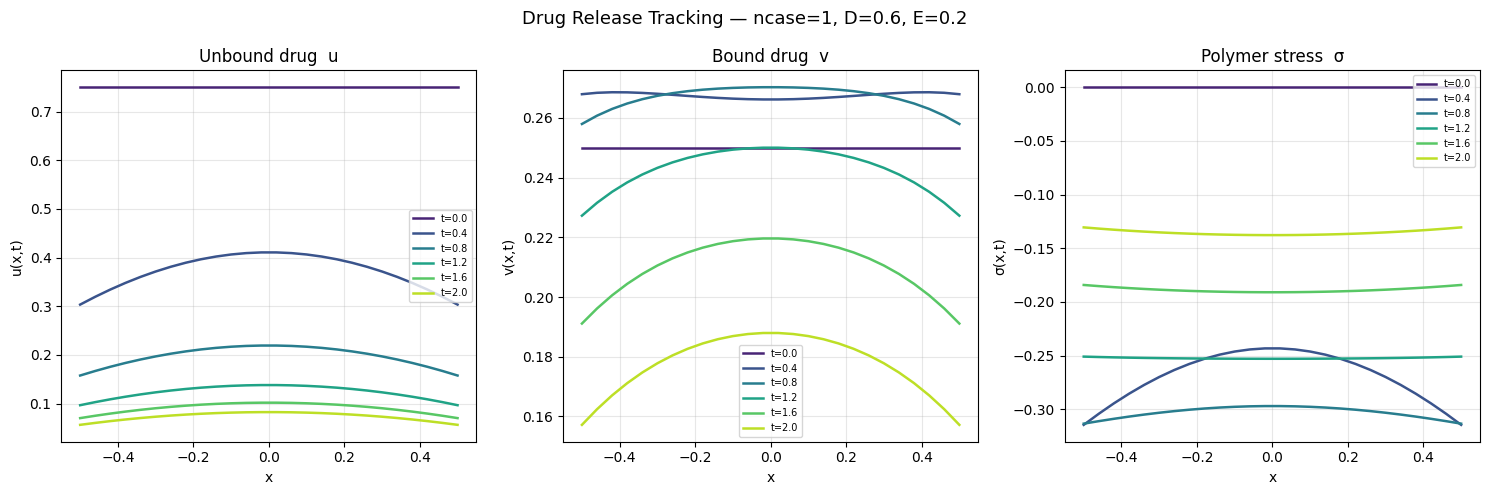

In [8]:
#Plots
colors = plt.cm.viridis(np.linspace(0.1, 0.9, nout))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Drug Release Tracking — ncase={ncase}, D={D}, E={E}", fontsize=13)

if ip == 1:
    for it in range(nout):
        lbl = f"t={tout[it]:.1f}"
        axes[0].plot(xg, u_xp[:,it], color=colors[it], label=lbl, lw=1.8)
        axes[1].plot(xg, v_xp[:,it], color=colors[it], label=lbl, lw=1.8)
        axes[2].plot(xg, s_xp[:,it], color=colors[it], label=lbl, lw=1.8)
    axes[0].set(xlabel="x", ylabel="u(x,t)", title="Unbound drug  u")
    axes[1].set(xlabel="x", ylabel="v(x,t)", title="Bound drug  v")
    axes[2].set(xlabel="x", ylabel="σ(x,t)", title="Polymer stress  σ")
    for ax in axes:
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
else:
    mid = nx // 2
    axes[0].plot(tout, u_xp[mid,:], 'b-', lw=2)
    axes[1].plot(tout, v_xp[mid,:], 'g-', lw=2)
    axes[2].plot(tout, s_xp[mid,:], 'r-', lw=2)
    axes[0].set(xlabel="t", ylabel="u(0,t)", title="Unbound drug u  at x=0")
    axes[1].set(xlabel="t", ylabel="v(0,t)", title="Bound drug v  at x=0")
    axes[2].set(xlabel="t", ylabel="σ(0,t)", title="Polymer stress σ  at x=0")
    for ax in axes:
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("drug_release.png", dpi=150, bbox_inches="tight")
plt.show()